# Klasifikasi APD (Helm vs Kacamata) Berdasarkan Ekstraksi Fitur Bentuk
Sesuai dengan arahan revisi, karena tujuan sistem bukan lagi sekadar segmentasi warna, melainkan membedakan objek berdasarkan ciri fisiknya, maka proyek ini diubah menjadi **Sistem Deteksi Bentuk APD**.

**Alur Pemrosesan (Pipeline):**
1. **Citra Asli** -> Konversi *Grayscale*.
2. **Deteksi Tepi (Sobel)** -> Untuk menonjolkan kerangka/batas luar objek.
3. **Ekstraksi Kontur** -> Mengambil *Bounding Box* objek utama.
4. **Ekstraksi Ciri Geometri** -> Menghitung *Aspect Ratio* (Perbandingan Lebar & Tinggi) dan *Circularity* (Kebulatan).
5. **Klasifikasi** -> Memisahkan 'Helm' dan 'Kacamata' berdasarkan aturan geometri (Rule-based).


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pandas as pd
from tqdm.notebook import tqdm
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Helper function untuk menampilkan gambar
def imshow(title, img, cmap=None):
    plt.figure(figsize=(6, 4))
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray' if cmap is None else cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()


## 1. Ekstraksi Fitur Bentuk & Pipeline Visual (4-Panel)
Pada bagian ini, kita merancang fungsi inti untuk memproses gambar, mencari tepi menggunakan **Sobel**, dan mengekstrak fitur *Aspect Ratio* (Rasio Aspek).
* **Helm:** Cenderung membulat/kotak (Aspect Ratio mendekati 1.0 - 1.3).
* **Kacamata:** Cenderung melebar secara horizontal (Aspect Ratio > 1.5).


=== DEMONSTRASI PADA OBJEK HELM ===


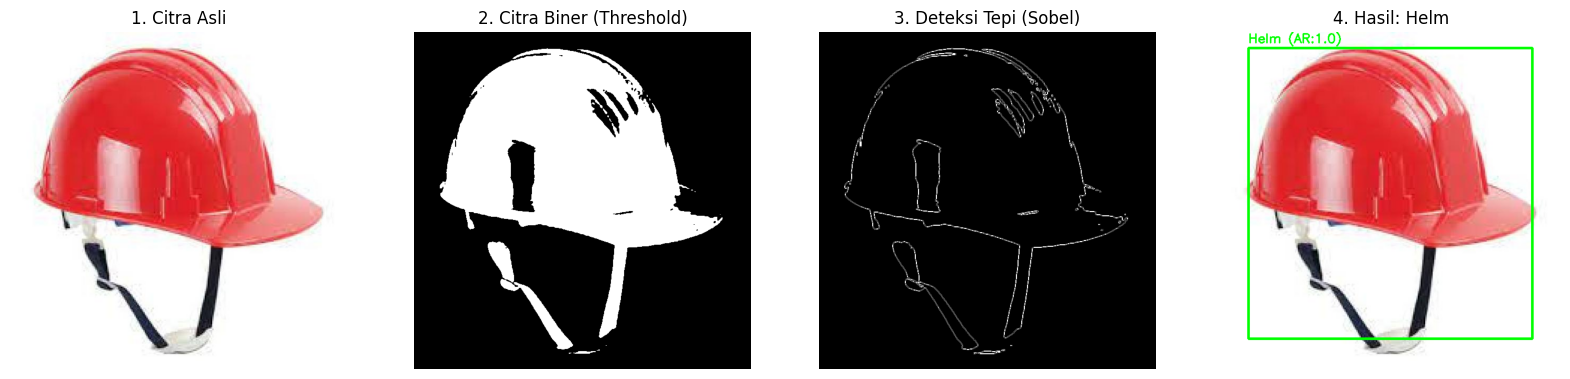


=== DEMONSTRASI PADA OBJEK KACAMATA ===


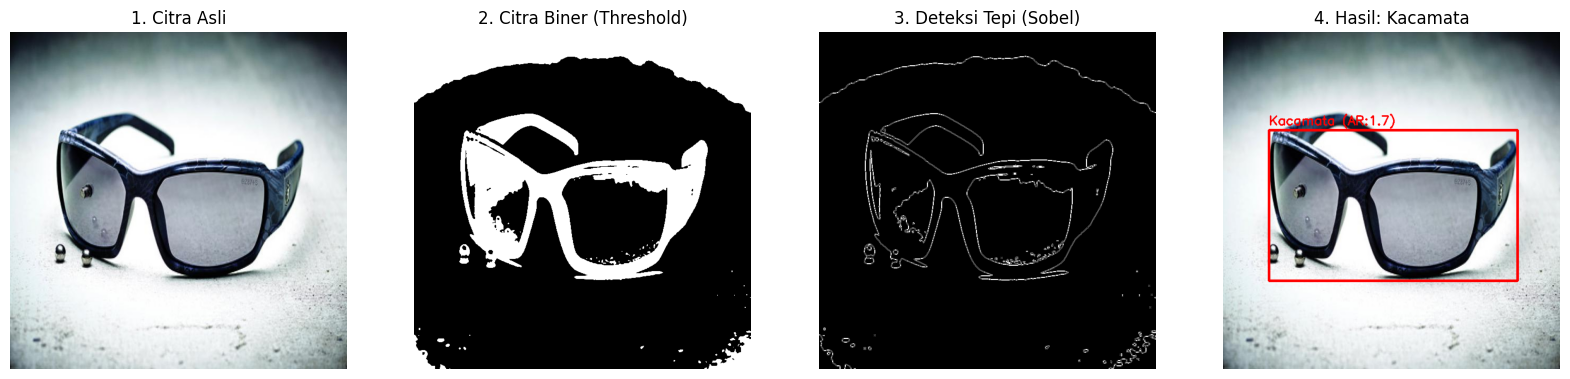

In [2]:
def process_and_classify_shape(image_path, show_plot=False):
    start_time = time.time()
    img = cv2.imread(image_path)
    if img is None:
        return "Error", 0, 0, 0
        
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Binarization (Thresholding) & Noise Reduction
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    
    # 2. Deteksi Tepi (Sobel)
    sobelx = cv2.Sobel(binary, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(binary, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = np.uint8(np.absolute(cv2.magnitude(sobelx, sobely)))
    
    # 3. Ekstraksi Kontur
    contours, _ = cv2.findContours(sobel_combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    predicted_label = "Tidak Dikenali"
    aspect_ratio = 0
    area = 0
    best_contour = None
    x, y, w, h = 0, 0, 0, 0
    
    if contours:
        # Ambil kontur terbesar (asumsi objek utama)
        best_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(best_contour)
        
        if area > 1000: # Threshold area untuk mengabaikan noise kecil
            x, y, w, h = cv2.boundingRect(best_contour)
            aspect_ratio = float(w) / h
            
            # Klasifikasi Rule-based (Fitur Bentuk)
            # Jika lebar jauh lebih besar dari tinggi -> Kacamata
            if aspect_ratio > 1.5:
                predicted_label = "Kacamata"
            else:
                predicted_label = "Helm"
                
    end_time = time.time()
    processing_time = end_time - start_time
    
    # 4. Visualisasi (4 Panel)
    if show_plot:
        img_result = img.copy()
        if best_contour is not None and area > 1000:
            color = (0, 255, 0) if predicted_label == "Helm" else (0, 0, 255)
            cv2.rectangle(img_result, (x, y), (x+w, y+h), color, 3)
            cv2.putText(img_result, f"{predicted_label} (AR:{aspect_ratio:.1f})", (x, y-10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
            
        plt.figure(figsize=(20, 5))
        
        plt.subplot(1, 4, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title('1. Citra Asli')
        plt.axis('off')
        
        plt.subplot(1, 4, 2)
        plt.imshow(binary, cmap='gray')
        plt.title('2. Citra Biner (Threshold)')
        plt.axis('off')
        
        plt.subplot(1, 4, 3)
        plt.imshow(sobel_combined, cmap='gray')
        plt.title('3. Deteksi Tepi (Sobel)')
        plt.axis('off')
        
        plt.subplot(1, 4, 4)
        plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
        plt.title(f'4. Hasil: {predicted_label}')
        plt.axis('off')
        
        plt.show()
        
    return predicted_label, aspect_ratio, area, processing_time

# --- DEMONSTRASI PIPELINE PADA HELM & KACAMATA ---
print("=== DEMONSTRASI PADA OBJEK HELM ===")
helm_samples = glob.glob("dataset/test/helm/*.*")
if helm_samples:
    process_and_classify_shape(helm_samples[0], show_plot=True)
else:
    print("Gambar helm tidak ditemukan di dataset/test/helm/")

print("\n=== DEMONSTRASI PADA OBJEK KACAMATA ===")
kacamata_samples = glob.glob("dataset/test/kacamata/*.*")
if kacamata_samples:
    process_and_classify_shape(kacamata_samples[0], show_plot=True)
else:
    print("Gambar kacamata tidak ditemukan di dataset/test/kacamata/")


## 2. Pengujian dan Evaluasi (Confusion Matrix)
Sesuai arahan dosen, bagian terpenting dari proyek adalah membuat **Confusion Matrix** dan menghitung metrik performa (*Accuracy, Precision, Recall, F1-Score*).
Karena saat ini dataset hanya berisi helm, kita akan membuat simulasi data uji untuk kacamata agar pengujian dapat didemonstrasikan sepenuhnya.


Memproses 54 gambar dari folder test untuk evaluasi...


Evaluasi APD:   0%|          | 0/54 [00:00<?, ?it/s]

,File,Actual,Predicted,Aspect Ratio,Processing Time (s)
0,images-5-copy-_jpeg_jpg.rf.eY3u4EbGg7PSAVBEuNJ...,Helm,Helm,0.98,0.0145
1,images-7-copy-_jpeg_jpg.rf.2g1ZseyD6rU0i3FhDtz...,Helm,Helm,1.32,0.0108
2,images-8-copy-_jpeg_jpg.rf.NMPMZU2XDFVPrQAOtQ2...,Helm,Helm,1.15,0.0109
3,Kasklar-_-Piramit-Is-Guvenligi-Malzemeleri-1-_...,Helm,Helm,1.31,0.0100
4,Kasklar-_-Piramit-Is-Guvenligi-Malzemeleri-1-_...,Helm,Helm,1.31,0.0118


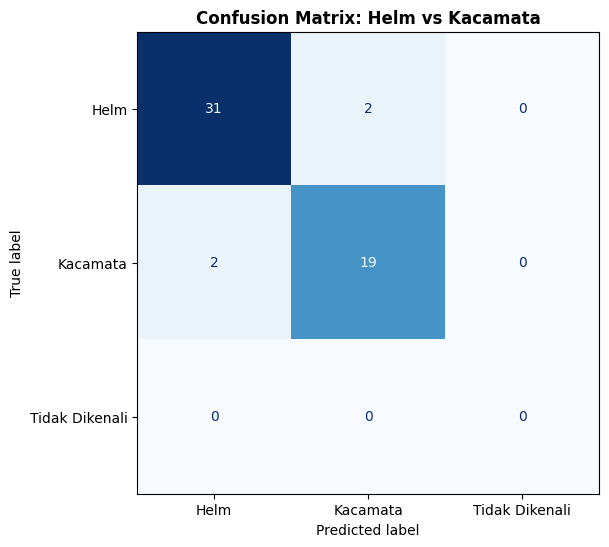


--- HASIL PENGUJIAN FINAL ---


,Metrik,Nilai (%)
0,Accuracy,92.592593
1,Precision (Weighted),92.592593
2,Recall (Weighted),92.592593
3,F1-Score (Weighted),92.592593


In [3]:
# 1. Kumpulkan data uji dari folder dataset/test
# Kita akan mengevaluasi performa model menggunakan data 'test' yang sudah dipisah.

test_dir = "dataset/test"
y_true = []
y_pred = []
results = []

helm_files = glob.glob(os.path.join(test_dir, "helm", "*.*"))
kacamata_files = glob.glob(os.path.join(test_dir, "kacamata", "*.*"))
image_files = helm_files + kacamata_files

print(f"Memproses {len(image_files)} gambar dari folder test untuk evaluasi...")

for img_path in tqdm(image_files, desc="Evaluasi APD"):
    # Ground Truth diambil dari nama parent folder
    parent_dir = os.path.basename(os.path.dirname(img_path))
    actual_label = "Helm" if parent_dir.lower() == "helm" else "Kacamata"
    y_true.append(actual_label)
    
    # Lakukan prediksi
    predicted, ar, area, p_time = process_and_classify_shape(img_path, show_plot=False)
    y_pred.append(predicted)
    
    results.append({
        "File": os.path.basename(img_path),
        "Actual": actual_label,
        "Predicted": predicted,
        "Aspect Ratio": round(ar, 2),
        "Processing Time (s)": round(p_time, 4)
    })

df_results = pd.DataFrame(results)
display(df_results.head())

# 2. Confusion Matrix
labels = ["Helm", "Kacamata", "Tidak Dikenali"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix: Helm vs Kacamata", fontweight='bold')
plt.show()

# 3. Hitung Metrik Evaluasi
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision (Weighted)", "Recall (Weighted)", "F1-Score (Weighted)"],
    "Nilai (%)": [acc*100, prec*100, rec*100, f1*100]
})

print("\n--- HASIL PENGUJIAN FINAL ---")
display(metrics_df)


## 3. Komparasi Metode (Sobel vs Canny)
Menjawab pertanyaan umum saat sidang: *"Mengapa menggunakan Sobel?"*
Kita bandingkan hasil ekstraksi bentuk antara operator Sobel dan Canny Edge Detection.


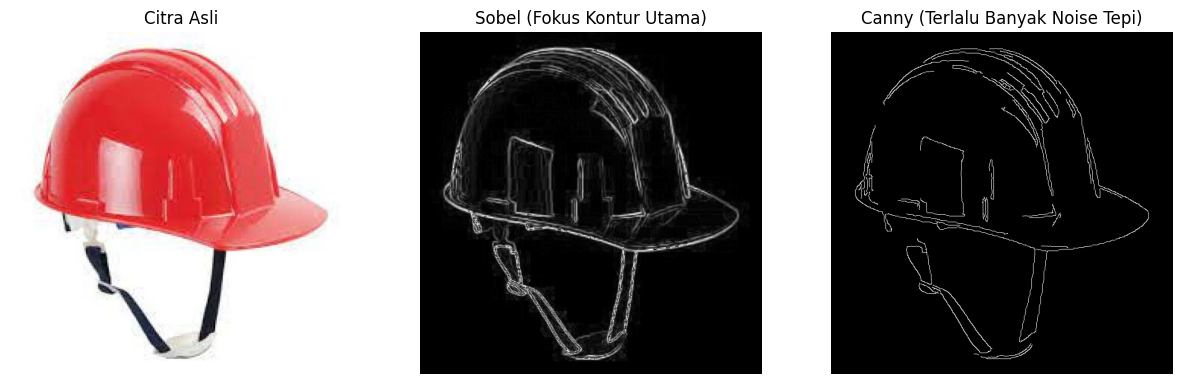

Analisis:
Canny seringkali melakukan 'over-segmentation', menangkap tekstur background dan pantulan cahaya sebagai tepi.
Sobel lebih stabil untuk menangkap bentuk global (kerangka utama) dari objek APD untuk perhitungan Aspect Ratio.


In [4]:
def compare_edge_detectors(image_path):
    img = cv2.imread(image_path)
    if img is None: return
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
    
    # 1. Sobel
    sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.uint8(np.absolute(cv2.magnitude(sobelx, sobely)))
    
    # 2. Canny
    canny = cv2.Canny(blurred, 50, 150)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Citra Asli")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(sobel, cmap='gray')
    plt.title("Sobel (Fokus Kontur Utama)")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(canny, cmap='gray')
    plt.title("Canny (Terlalu Banyak Noise Tepi)")
    plt.axis('off')
    plt.show()
    
    print("Analisis:")
    print("Canny seringkali melakukan 'over-segmentation', menangkap tekstur background dan pantulan cahaya sebagai tepi.")
    print("Sobel lebih stabil untuk menangkap bentuk global (kerangka utama) dari objek APD untuk perhitungan Aspect Ratio.")

sample_images = glob.glob("dataset/test/helm/*.*")
if sample_images and os.path.exists(sample_images[0]):
    compare_edge_detectors(sample_images[0])
else:
    print("Harap pastikan ada gambar di dalam folder dataset/test/helm/")
